# Exploratory Data Analysis — Telco Customer Churn

**Project:** Customer Churn Prediction MLOps System  
**Dataset:** IBM Telco Customer Churn  
**Libraries:** Pandas, NumPy, Matplotlib, Seaborn  

---

##  Goal of this Notebook

Before building any machine learning model, we need to deeply understand our data. This notebook answers:

1. What does the dataset look like? (shape, types, nulls)
2. Is the target variable balanced or imbalanced?
3. How are numerical features distributed across churn vs non-churn?
4. Which categorical features have the strongest relationship with churn?
5. Are there correlations between features we should be aware of?
6. What preprocessing decisions are justified by the data?

---

##  Table of Contents

1. Import Libraries
2. Load & Inspect Dataset
3. Data Cleaning
4. Target Variable Analysis (Class Imbalance)
5. Numerical Feature Analysis
6. Categorical Feature Analysis
7. Contract Type Deep Dive
8. Correlation Heatmap
9. Scatter Plot — Tenure vs Monthly Charges
10. Add-on Services Impact
11. Key Insights & Preprocessing Justifications

---
## 1.  Import Libraries

We import the standard data science stack:
- **pandas** — for loading and manipulating tabular data
- **numpy** — for numerical computations
- **matplotlib** — base plotting library
- **seaborn** — high-level statistical visualization built on matplotlib
- **warnings** — to suppress non-critical warnings during execution

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display all columns in pandas output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Define a consistent color palette
BLUE  = '#2563EB'
RED   = '#DC2626'
GREEN = '#16A34A'
AMBER = '#D97706'
PALETTE = [GREEN, RED]   # Green = No Churn, Red = Churn

print('Libraries imported successfully')

Libraries imported successfully


---
## 2.  Load & Inspect Dataset

We load the raw CSV file using `pd.read_csv()`. The dataset contains information about 7,043 telecom customers including:
- **Demographics** — gender, age, partner, dependents
- **Services** — phone, internet, security, streaming
- **Billing** — contract type, payment method, charges
- **Target** — whether the customer churned (`Yes`/`No`)

We first look at:
- `.shape` → rows and columns
- `.dtypes` → data type of each column
- `.head()` → first 5 rows
- `.info()` → summary including null counts

In [ ]:
# Load the dataset
df = pd.read_csv('/content/telco_churn.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head()

Dataset shape: 7,043 rows × 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Get a full summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Check statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [ ]:
# Check for missing values in each column
null_summary = pd.DataFrame({
    'Null Count':   df.isnull().sum(),
    'Null %':       (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type':    df.dtypes,
    'Unique Values': df.nunique()
})

print('Column Summary:')
null_summary

Column Summary:


,Null Count,Null %,Data Type,Unique Values
customerID,0,0.00,object,7043
gender,0,0.00,object,2
SeniorCitizen,0,0.00,int64,2
Partner,0,0.00,object,2
Dependents,0,0.00,object,2
tenure,0,0.00,int64,73
PhoneService,0,0.00,object,2
MultipleLines,0,0.00,object,3
InternetService,0,0.00,object,3
OnlineSecurity,0,0.00,object,3


 The `TotalCharges` column appears to have no nulls according to `.info()`, but it is stored as `object` (string) type instead of `float`.

In [ ]:
# converting it and checking what fails
tc_converted = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Rows where conversion failed (became NaN)
problem_rows = df[tc_converted.isnull()]
print(f'Rows with invalid TotalCharges: {len(problem_rows)}')
print()
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Rows with invalid TotalCharges: 11

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


 These 11 rows have `tenure = 0` (brand new customers who never completed a billing cycle). Their `TotalCharges` is a blank string `" "`. Droping these rows during cleaning since they represent less than 0.2% of data and have no billing history to learn from.

---
## 3.  Data Cleaning

Based on the inspection, need to:
1. Convert `TotalCharges` from string to float
2. Drop the 11 rows with blank `TotalCharges`
3. Drop `customerID` — it's just an identifier, not a feature
4. Encode the target `Churn` column from `Yes/No` → `1/0`

In [ ]:
# Step 1: Fix TotalCharges — convert to numeric, blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Drop rows where TotalCharges is NaN (the 11 new customers)
df_clean = df.dropna(subset=['TotalCharges']).copy()
print(f'Rows before cleaning: {len(df):,}')
print(f'Rows after  cleaning: {len(df_clean):,}')
print(f'Rows dropped        : {len(df) - len(df_clean)} (tenure=0 customers)')

# Step 3: Encode target variable — Yes → 1, No → 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Step 4: Verify TotalCharges is now numeric
print(f'TotalCharges dtype: {df_clean["TotalCharges"].dtype}')
print(f'Churn unique values: {df_clean["Churn"].unique()}')
print('Data cleaned successfully')

Rows before cleaning: 7,043
Rows after  cleaning: 7,032
Rows dropped        : 11 (tenure=0 customers)
TotalCharges dtype: float64
Churn unique values: [0 1]
Data cleaned successfully


---
## 4. Target Variable Analysis - Class Imbalance

The target variable is `Churn` (1 = churned, 0 = stayed). Before modeling, we need to understand if the classes are **balanced** or **imbalanced**.

**Why does this matter?**  
If 90% of customers didn't churn, a model that predicts "No Churn" every time would still get 90% accuracy — but be completely useless. Class imbalance needs to be handled explicitly.

We use `value_counts()` and visualize with a bar chart and pie chart.

In [ ]:
# Count and percentage of each class
churn_counts = df_clean['Churn'].value_counts()
churn_pct    = df_clean['Churn'].value_counts(normalize=True) * 100

print(' Target Variable Distribution:')
print(f'   No Churn (0): {churn_counts[0]:,} customers ({churn_pct[0]:.1f}%)')
print(f'   Churn    (1): {churn_counts[1]:,} customers ({churn_pct[1]:.1f}%)')
print(f'   Imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1')
print()
print('  This is an IMBALANCED dataset — we will apply SMOTE in preprocessing')

 Target Variable Distribution:
   No Churn (0): 5,163 customers (73.4%)
   Churn    (1): 1,869 customers (26.6%)
   Imbalance ratio: 2.8:1

  This is an IMBALANCED dataset — we will apply SMOTE in preprocessing


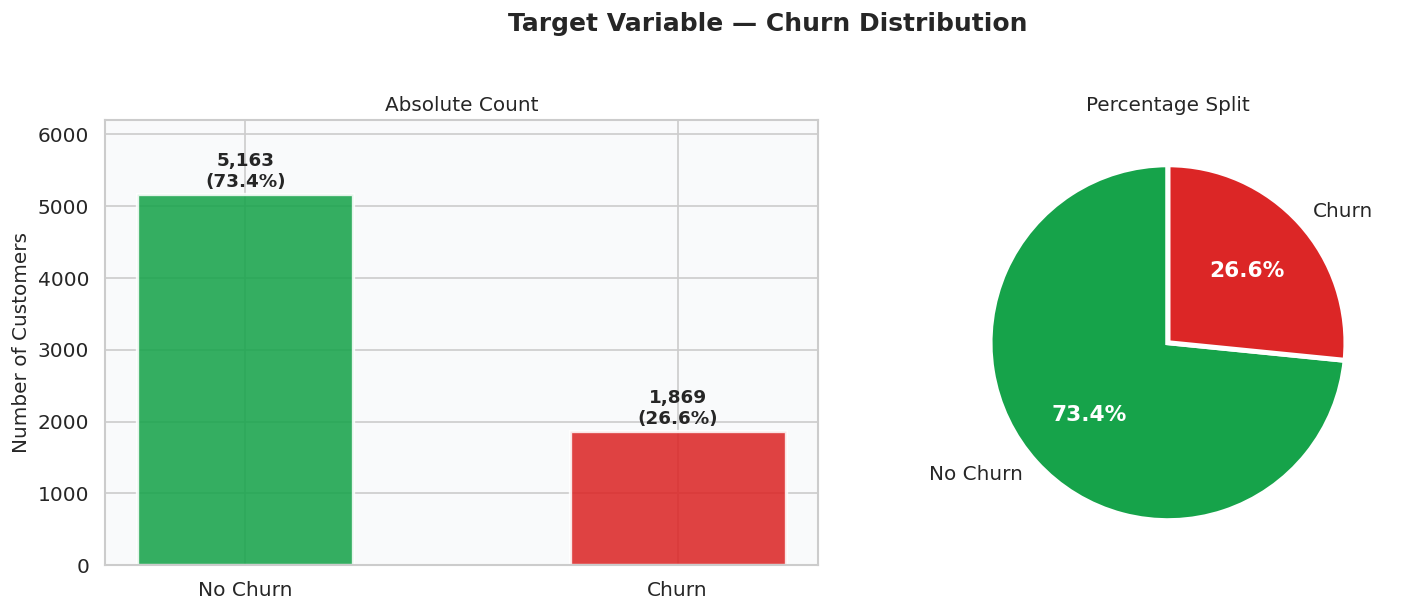


 Key Finding: Only 26.5% of customers churned — significant class imbalance!
   → Solution: Apply SMOTE (Synthetic Minority Oversampling Technique) during preprocessing


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold', y=1.02)

# Shows absolute count of each class side by side
bars = axes[0].bar(
    ['No Churn', 'Churn'],
    churn_counts.values,
    color=[GREEN, RED],
    alpha=0.87,
    edgecolor='white',
    linewidth=2,
    width=0.5
)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('Absolute Count', fontsize=12)

# Add value labels on top of each bar
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, churn_counts.max() * 1.2)
axes[0].set_facecolor('#f9fafb')

# --- Pie Chart ---
# Shows the proportion visually
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=['No Churn', 'Churn'],
    colors=[GREEN, RED],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title('Percentage Split', fontsize=12)

plt.tight_layout()
plt.show()

print('\n Key Finding: Only 26.5% of customers churned — significant class imbalance!')
print('   → Solution: Apply SMOTE (Synthetic Minority Oversampling Technique) during preprocessing')

---
## 5.  Numerical Feature Analysis

There are 3 numerical features in this dataset:
- **tenure** - how many months the customer has been with the company
- **MonthlyCharges** - how much they pay per month
- **TotalCharges** - total amount paid over lifetime

We analyze these using:
- **Histogram** - shows the distribution shape for churners vs non-churners
- **Boxplot** - shows median, spread, and outliers for both groups
- **KDE Plot** - smoothed density curve showing overlap between groups

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Print statistical comparison for churners vs non-churners
print(' Numerical Features — Mean Comparison by Churn Status:')
print('-' * 65)
for col in num_cols:
    mean_churn    = df_clean[df_clean['Churn'] == 1][col].mean()
    mean_no_churn = df_clean[df_clean['Churn'] == 0][col].mean()
    diff = ((mean_churn - mean_no_churn) / mean_no_churn) * 100
    print(f'  {col:<20} No Churn: {mean_no_churn:>8.2f}  |  Churn: {mean_churn:>8.2f}  |  Diff: {diff:+.1f}%')

 Numerical Features — Mean Comparison by Churn Status:
-----------------------------------------------------------------
  tenure               No Churn:    37.65  |  Churn:    17.98  |  Diff: -52.2%
  MonthlyCharges       No Churn:    61.31  |  Churn:    74.44  |  Diff: +21.4%
  TotalCharges         No Churn:  2555.34  |  Churn:  1531.80  |  Diff: -40.1%


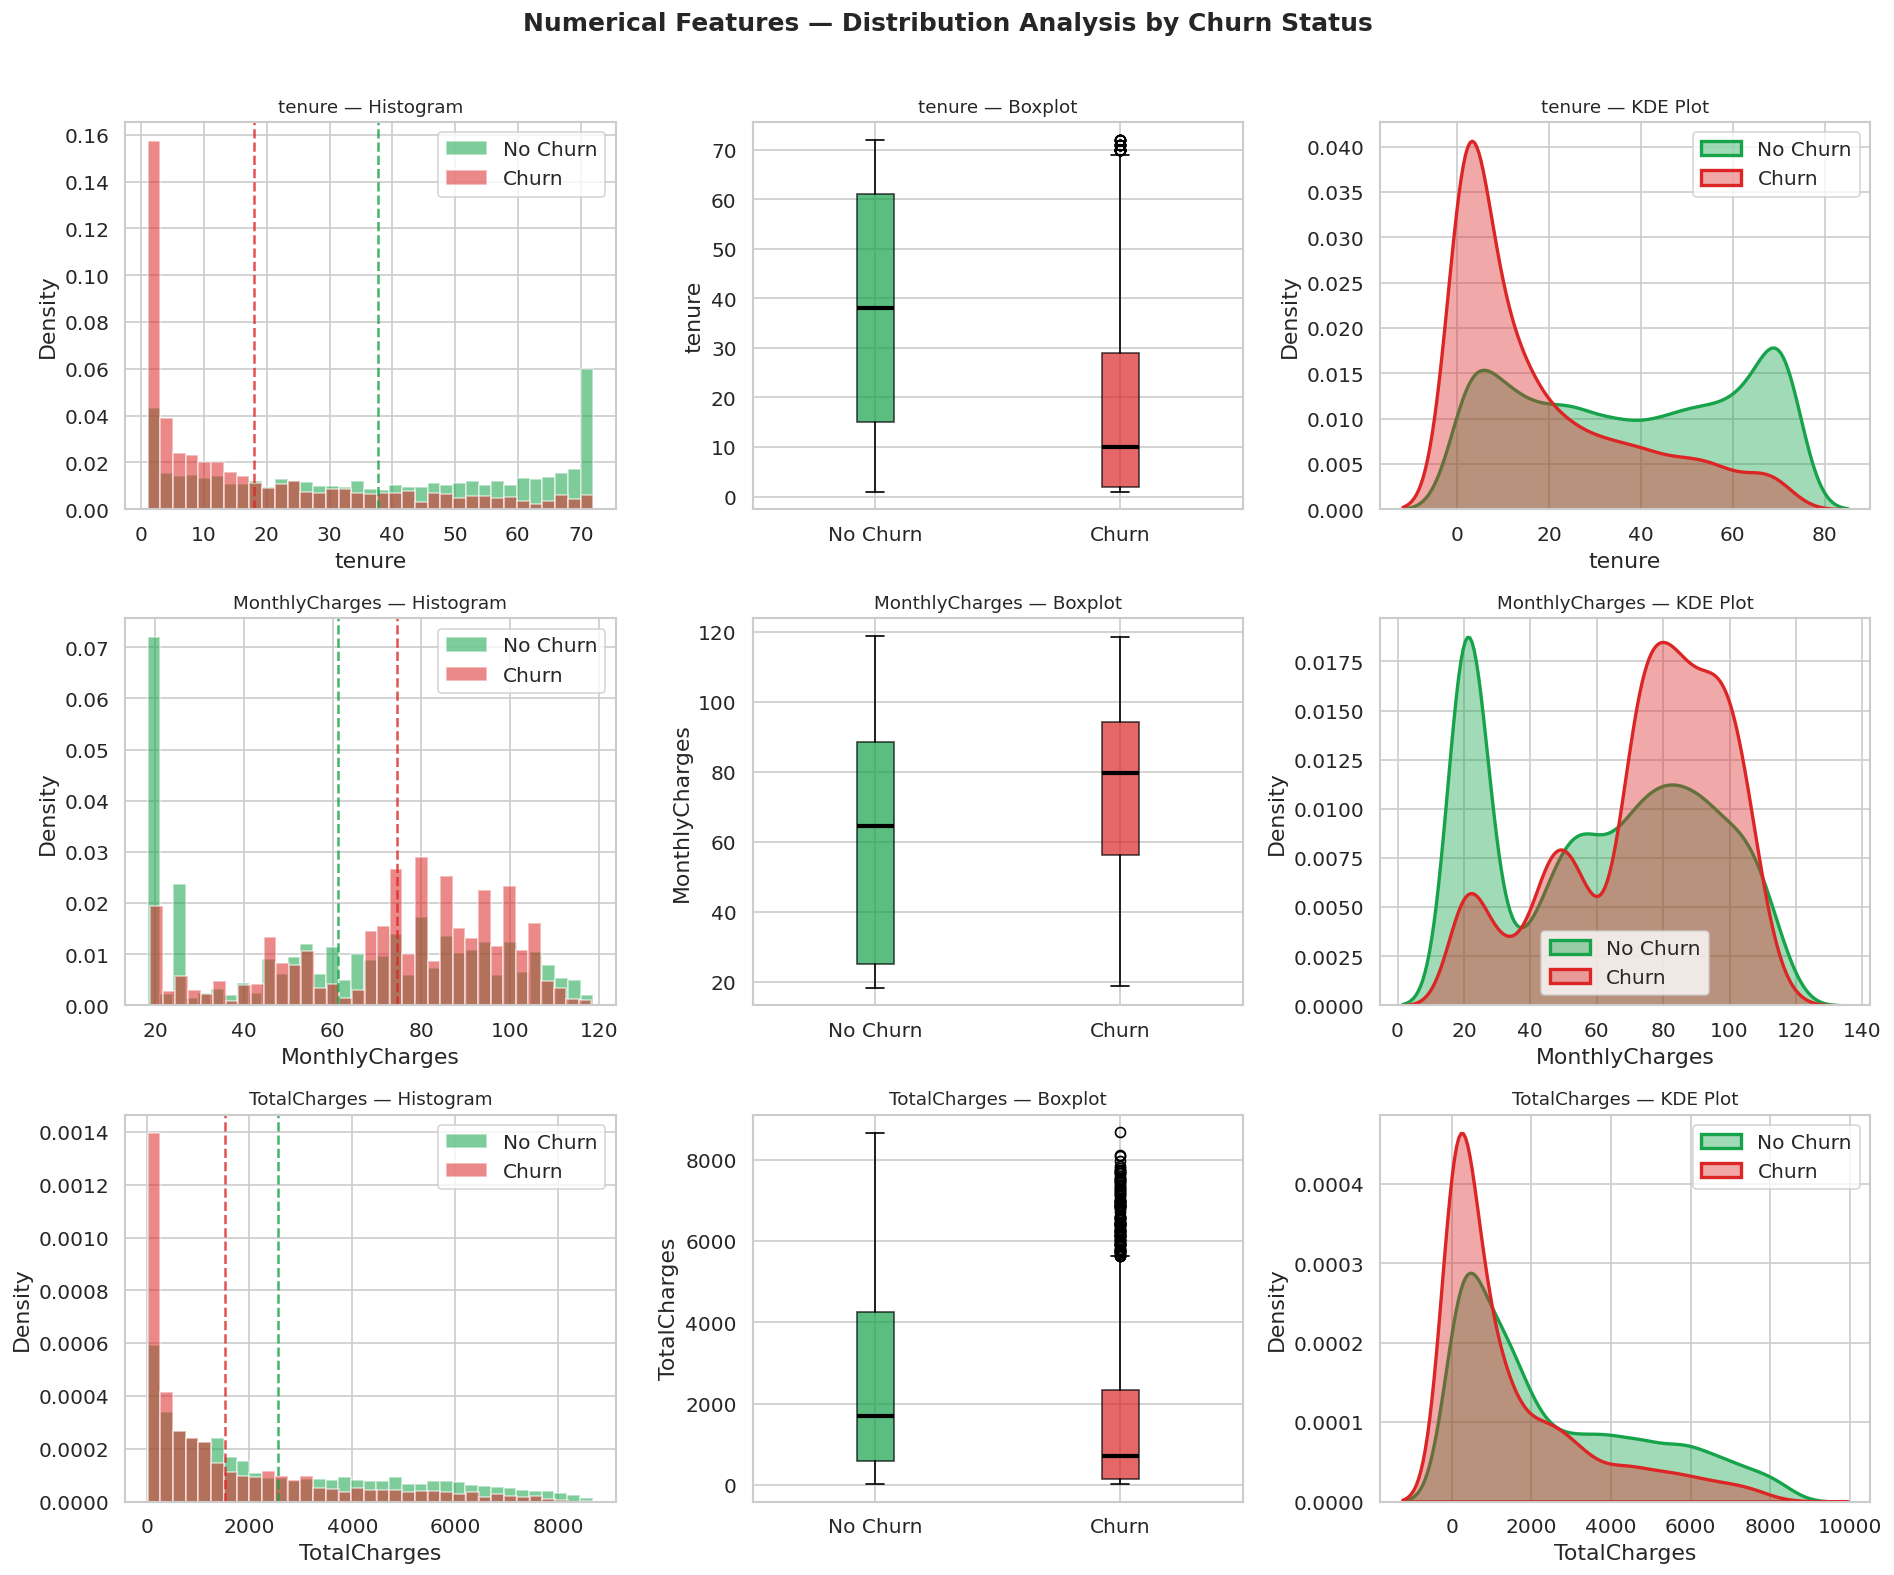

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Numerical Features — Distribution Analysis by Churn Status',
             fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(num_cols):
    churn_no  = df_clean[df_clean['Churn'] == 0][col]
    churn_yes = df_clean[df_clean['Churn'] == 1][col]

    # --- Column 1: Histogram ---
    # Overlapping histograms show where distributions differ
    # density=True normalizes both groups to same scale despite different sizes
    axes[i, 0].hist(churn_no,  bins=35, alpha=0.55, color=GREEN,
                    label='No Churn', density=True, edgecolor='white')
    axes[i, 0].hist(churn_yes, bins=35, alpha=0.55, color=RED,
                    label='Churn',    density=True, edgecolor='white')
    axes[i, 0].set_title(f'{col} — Histogram', fontsize=11)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')
    axes[i, 0].legend()
    # Add vertical lines for means
    axes[i, 0].axvline(churn_no.mean(),  color=GREEN, linestyle='--', linewidth=1.5, alpha=0.8)
    axes[i, 0].axvline(churn_yes.mean(), color=RED,   linestyle='--', linewidth=1.5, alpha=0.8)

    # --- Column 2: Boxplot ---
    # Boxplot shows: median (middle line), IQR (box), whiskers (range), outliers (dots)
    bp = axes[i, 1].boxplot(
        [churn_no.values, churn_yes.values],
        patch_artist=True,
        labels=['No Churn', 'Churn'],
        medianprops={'color': 'black', 'linewidth': 2.5}
    )
    bp['boxes'][0].set_facecolor(GREEN); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(RED);   bp['boxes'][1].set_alpha(0.7)
    axes[i, 1].set_title(f'{col} — Boxplot', fontsize=11)
    axes[i, 1].set_ylabel(col)

    # --- Column 3: KDE Plot (Kernel Density Estimate) ---
    # A smooth curve that estimates the probability distribution
    # Better than histogram for seeing the true shape
    sns.kdeplot(churn_no,  ax=axes[i, 2], color=GREEN, fill=True,
                alpha=0.4, label='No Churn', linewidth=2)
    sns.kdeplot(churn_yes, ax=axes[i, 2], color=RED,   fill=True,
                alpha=0.4, label='Churn',    linewidth=2)
    axes[i, 2].set_title(f'{col} — KDE Plot', fontsize=11)
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Key numerical insights
print(' KEY INSIGHTS FROM NUMERICAL FEATURES:')
print()
print('  tenure:')
print('    → Churners have LOW tenure (avg ~18 months) — they leave early')
print('    → Non-churners have HIGH tenure (avg ~37 months) — loyal long-term customers')
print('    → This justifies creating a TenureGroup feature (0-1yr, 1-2yr, 2-4yr, 4+yr)')
print()
print('  MonthlyCharges:')
print('    → Churners pay MORE per month (avg ~$74) vs stayers (avg ~$61)')
print('    → High charges + short tenure = high churn risk')
print('    → This justifies creating a ChargePerTenure feature')
print()
print('  TotalCharges:')
print('    → Churners have LOW total charges (avg ~$1,532) despite high monthly charges')
print('    → Because they leave early, their total lifetime value is lower')
print('    → Highly correlated with tenure (we will verify in correlation heatmap)')

 KEY INSIGHTS FROM NUMERICAL FEATURES:

  tenure:
    → Churners have LOW tenure (avg ~18 months) — they leave early
    → Non-churners have HIGH tenure (avg ~37 months) — loyal long-term customers
    → This justifies creating a TenureGroup feature (0-1yr, 1-2yr, 2-4yr, 4+yr)

  MonthlyCharges:
    → Churners pay MORE per month (avg ~$74) vs stayers (avg ~$61)
    → High charges + short tenure = high churn risk
    → This justifies creating a ChargePerTenure feature

  TotalCharges:
    → Churners have LOW total charges (avg ~$1,532) despite high monthly charges
    → Because they leave early, their total lifetime value is lower
    → Highly correlated with tenure (we will verify in correlation heatmap)


---
## 6.  Categorical Feature Analysis

 Analyzing how churn rate varies across categories. For each categorical feature,  calculate the **churn rate** (% of customers in that category who churned) using `groupby()` and `mean()`.

This helps to identify which categories are strong predictors of churn.

In [ ]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Calculate churn rate per category and print a summary
print(' Churn Rate per Categorical Feature:')
print('=' * 60)
overall_churn = df_clean['Churn'].mean() * 100
print(f'Overall average churn rate: {overall_churn:.1f}%')
print()

for col in cat_cols:
    churn_rate = (df_clean.groupby(col)['Churn'].mean() * 100).sort_values(ascending=False)
    print(f'  {col}:')
    for cat, rate in churn_rate.items():
        flag = 'HIGH' if rate > overall_churn * 1.3 else ('LOW' if rate < overall_churn * 0.7 else '  AVG')
        print(f'    {str(cat):<35} {rate:.1f}%  {flag}')
    print()

 Churn Rate per Categorical Feature:
Overall average churn rate: 26.6%

  gender:
    Female                              27.0%    AVG
    Male                                26.2%    AVG

  SeniorCitizen:
    1                                   41.7%  HIGH
    0                                   23.7%    AVG

  Partner:
    No                                  33.0%    AVG
    Yes                                 19.7%    AVG

  Dependents:
    No                                  31.3%    AVG
    Yes                                 15.5%  LOW

  PhoneService:
    Yes                                 26.7%    AVG
    No                                  25.0%    AVG

  InternetService:
    Fiber optic                         41.9%  HIGH
    DSL                                 19.0%    AVG
    No                                  7.4%  LOW

  Contract:
    Month-to-month                      42.7%  HIGH
    One year                            11.3%  LOW
    Two year                          

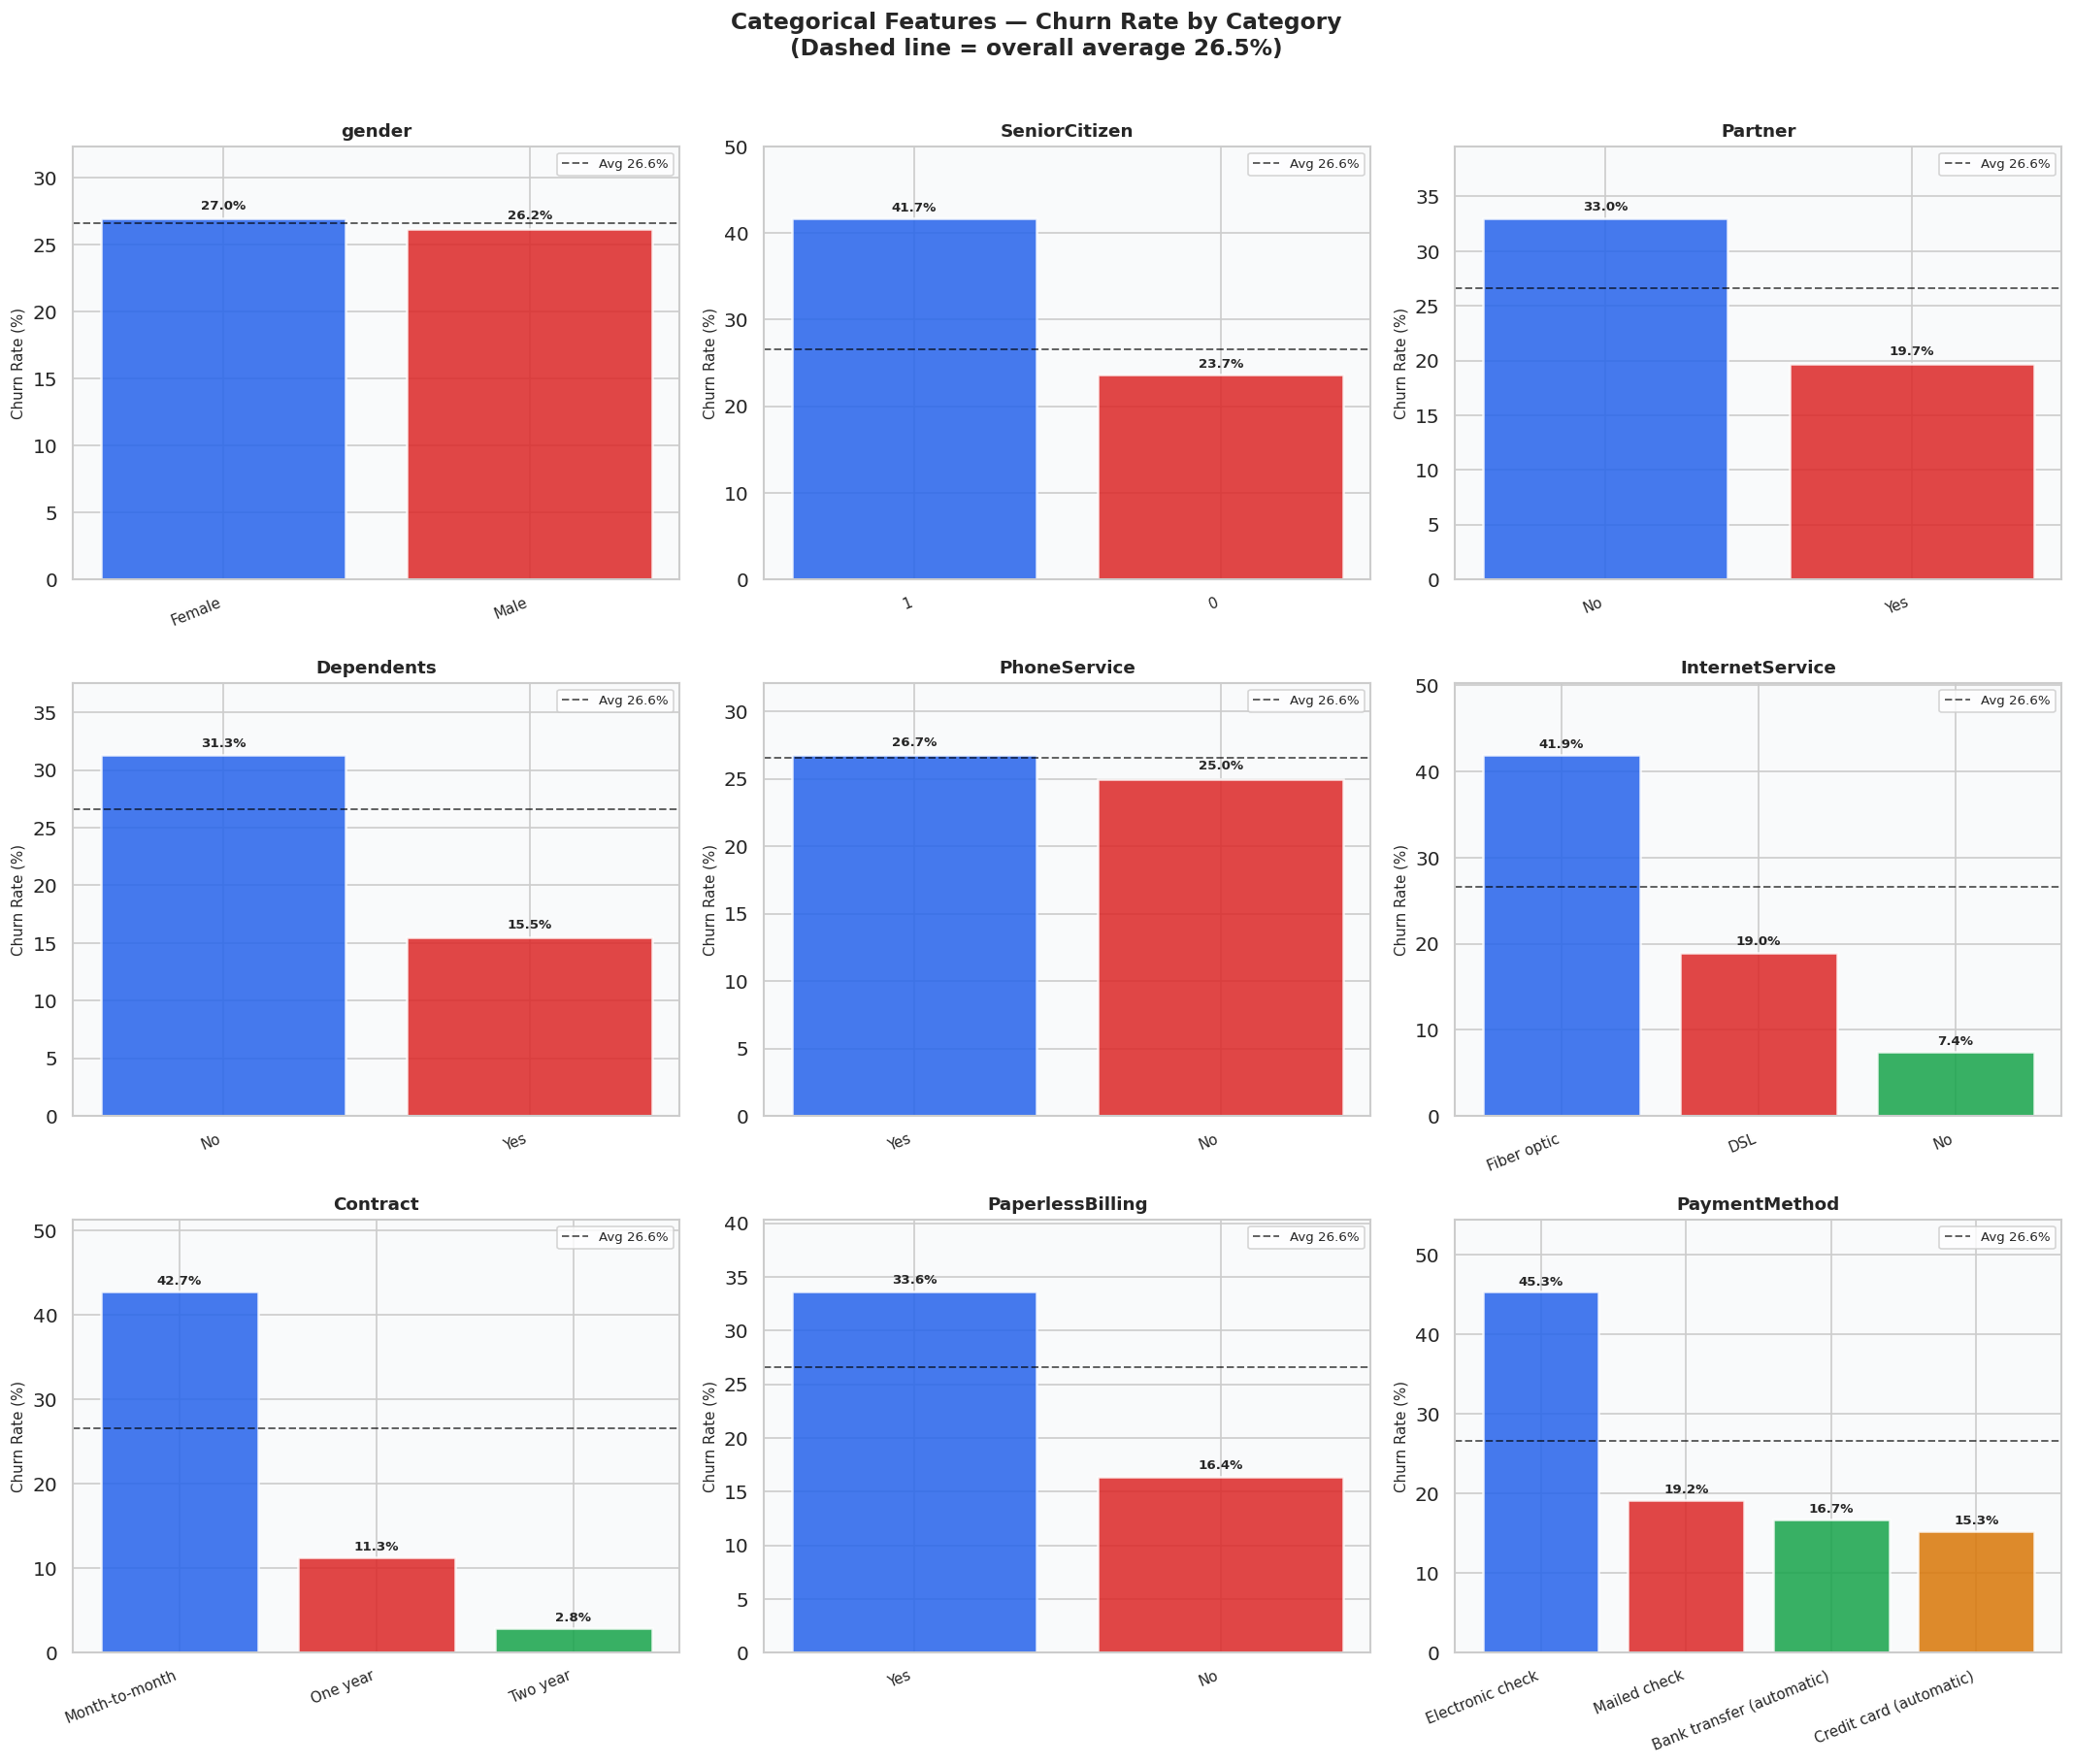

In [ ]:
# Plot churn rate for all categorical features in a grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Categorical Features — Churn Rate by Category\n(Dashed line = overall average 26.5%)',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

bar_colors = [BLUE, RED, GREEN, AMBER, '#8B5CF6', '#06B6D4', '#EC4899', '#F97316', '#14B8A6']

for i, col in enumerate(cat_cols):
    churn_rate = (df_clean.groupby(col)['Churn'].mean() * 100).sort_values(ascending=False)

    # Use different colors for each bar so categories are visually distinct
    colors = bar_colors[:len(churn_rate)]
    bars = axes[i].bar(
        range(len(churn_rate)),
        churn_rate.values,
        color=colors,
        alpha=0.85,
        edgecolor='white',
        linewidth=1.5
    )

    # x-axis labels
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=22, ha='right', fontsize=9)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)', fontsize=9)

    # Dashed horizontal line = overall average churn rate
    # Bars above this line = higher churn risk than average
    axes[i].axhline(y=overall_churn, color='black', linestyle='--',
                    linewidth=1.2, alpha=0.6, label=f'Avg {overall_churn:.1f}%')
    axes[i].legend(fontsize=8)

    # Add value labels on each bar
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )
    axes[i].set_ylim(0, churn_rate.max() * 1.2)
    axes[i].set_facecolor('#f9fafb')

plt.tight_layout()
plt.show()

---
## 7.  Contract Type Deep Dive

From the previous analysis, **Contract type** is clearly the strongest categorical predictor of churn.

 Digging deeper:
- How does churn rate vary across contract types?
- Does tenure moderate the contract-churn relationship?
- Use a grouped bar chart with `pd.cut()` to create tenure groups

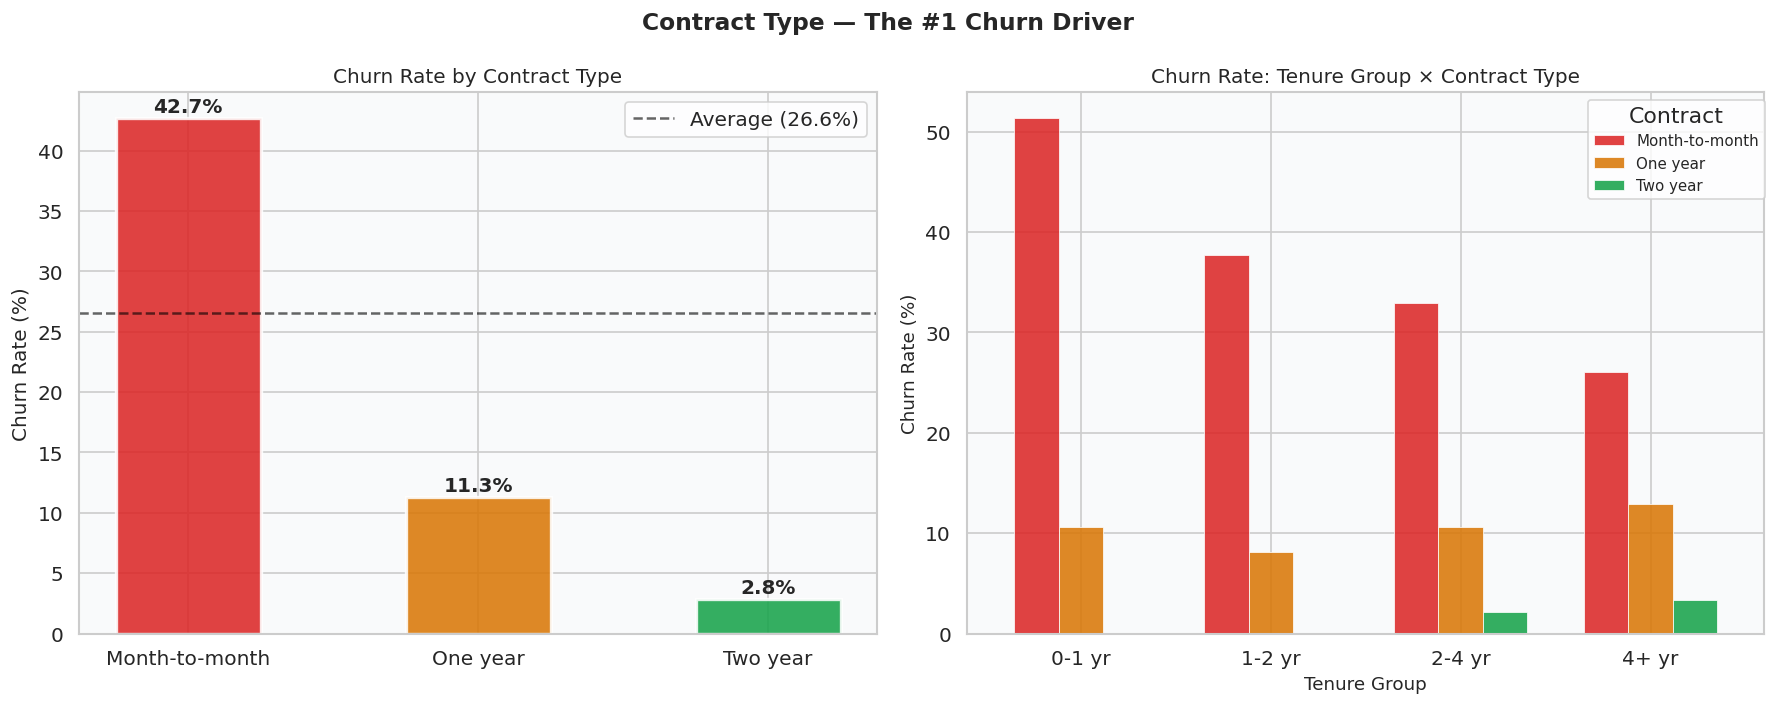

💡 Key Finding: Month-to-month customers churn at 43% vs 11% (1yr) and 3% (2yr)
   → Even in the 4+ yr group, month-to-month customers still churn 3x more!
   → Contract is THE most important feature for predicting churn


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Contract Type — The #1 Churn Driver', fontsize=14, fontweight='bold')

# --- Left: Churn Rate by Contract ---
contract_churn = df_clean.groupby('Contract')['Churn'].mean() * 100
contract_churn = contract_churn.sort_values(ascending=False)

colors_contract = [RED, AMBER, GREEN]
bars = axes[0].bar(
    contract_churn.index,
    contract_churn.values,
    color=colors_contract,
    alpha=0.87,
    edgecolor='white',
    linewidth=2,
    width=0.5
)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_title('Churn Rate by Contract Type', fontsize=12)
axes[0].axhline(y=overall_churn, color='black', linestyle='--',
                linewidth=1.5, alpha=0.6, label=f'Average ({overall_churn:.1f}%)')
axes[0].legend()
axes[0].set_facecolor('#f9fafb')

for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# --- Right: Churn Rate by Tenure Group × Contract ---
# pd.cut() bins the continuous tenure variable into groups
# This reveals whether contract type matters equally across all tenures
df_clean['TenureGroup'] = pd.cut(
    df_clean['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 yr', '1-2 yr', '2-4 yr', '4+ yr']
)

tenure_contract = df_clean.groupby(['TenureGroup', 'Contract'])['Churn'].mean().unstack() * 100
tenure_contract.plot(
    kind='bar', ax=axes[1],
    color=[RED, AMBER, GREEN],
    alpha=0.87, edgecolor='white', linewidth=0.5, width=0.7
)
axes[1].set_title('Churn Rate: Tenure Group × Contract Type', fontsize=12)
axes[1].set_xlabel('Tenure Group', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].legend(title='Contract', bbox_to_anchor=(1.01, 1), fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_facecolor('#f9fafb')

plt.tight_layout()
plt.show()

print('💡 Key Finding: Month-to-month customers churn at 43% vs 11% (1yr) and 3% (2yr)')
print('   → Even in the 4+ yr group, month-to-month customers still churn 3x more!')
print('   → Contract is THE most important feature for predicting churn')

---
## 8. Correlation Heatmap

A **correlation heatmap** shows the pairwise linear relationship between all features.
- Values range from **-1 to +1**
- **+1** = perfect positive correlation (both increase together)
- **-1** = perfect negative correlation (one increases, other decreases)
- **0** = no linear relationship

We encode all categorical columns numerically first, then compute Pearson correlation using `.corr()`.

We use `np.triu()` to mask the upper triangle (it's a mirror image) so the plot is cleaner.

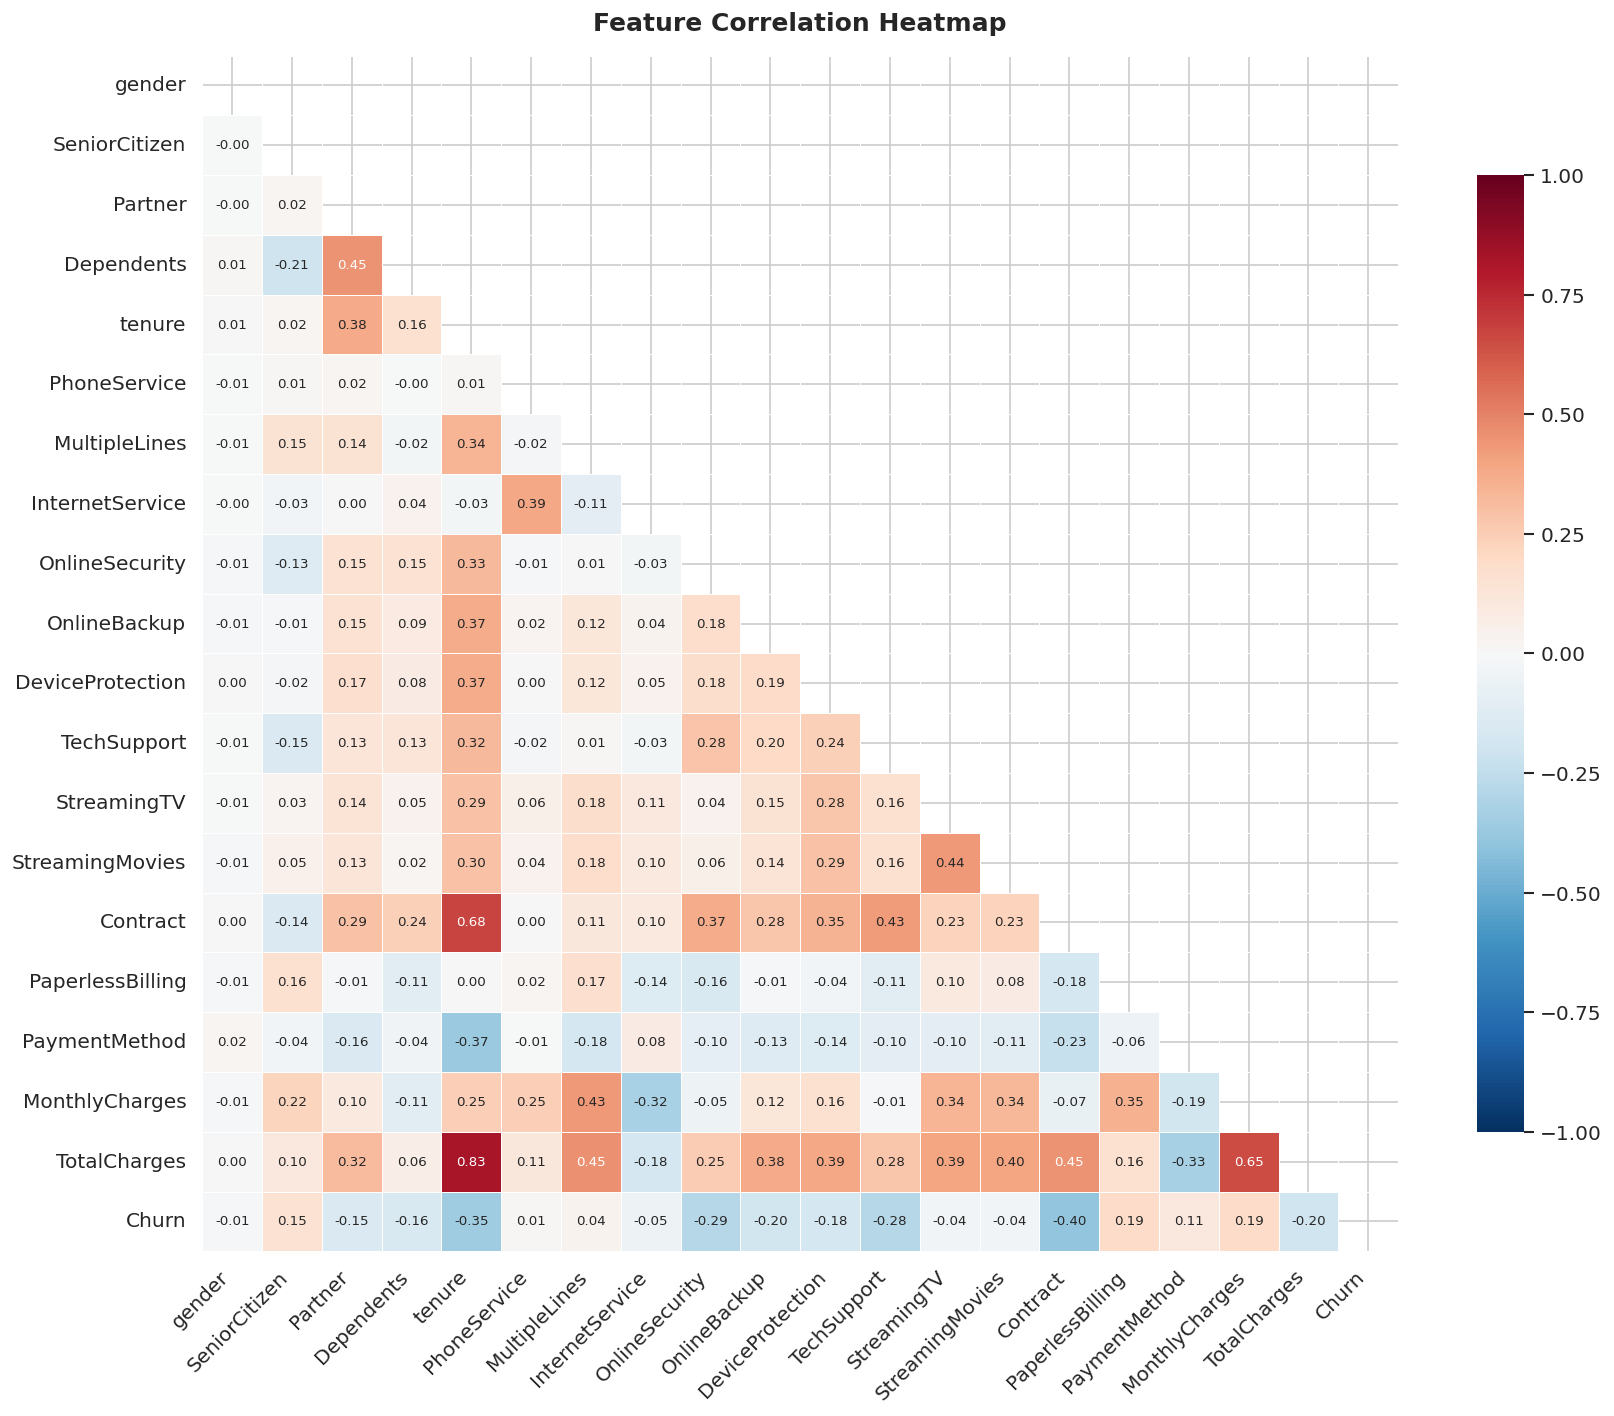

In [ ]:
# Encode all categorical columns numerically for correlation computation
# pd.Categorical().codes assigns integer codes to categories
df_enc = df_clean.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = pd.Categorical(df_enc[col]).codes

# Drop customerID — it's an ID, not a feature
df_enc = df_enc.drop(columns=['customerID', 'TenureGroup'], errors='ignore')

# Compute Pearson correlation matrix
corr_matrix = df_enc.corr()

# Create mask for upper triangle — we only need lower triangle (it's symmetric)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Show correlation values in each cell
    fmt='.2f',            # 2 decimal places
    cmap='RdBu_r',        # Red = negative, Blue = positive correlation
    center=0,             # Center the colormap at 0
    square=True,          # Make cells square
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8},
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Extract correlations with the target variable (Churn) and sort by absolute value
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print('🔗 Feature Correlations with CHURN (sorted by strength):')
print('-' * 60)
for feat, val in churn_corr.head(15).items():
    bar = '█' * int(abs(val) * 20)
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'  {feat:<25} {val:+.3f}  {bar:<22}  ({direction})')

print()
print('💡 Notable correlations:')
print('  TotalCharges ↔ tenure: very high (0.83) — multicollinearity!')
print('  → ChargePerTenure feature helps reduce this by combining both')
print('  Contract type is the strongest negative predictor (longer = less churn)')

🔗 Feature Correlations with CHURN (sorted by strength):
------------------------------------------------------------
  Contract                  -0.396  ███████                 (↓ negative)
  tenure                    -0.354  ███████                 (↓ negative)
  OnlineSecurity            -0.289  █████                   (↓ negative)
  TechSupport               -0.282  █████                   (↓ negative)
  TotalCharges              -0.199  ███                     (↓ negative)
  OnlineBackup              -0.195  ███                     (↓ negative)
  MonthlyCharges            +0.193  ███                     (↑ positive)
  PaperlessBilling          +0.191  ███                     (↑ positive)
  DeviceProtection          -0.178  ███                     (↓ negative)
  Dependents                -0.163  ███                     (↓ negative)
  SeniorCitizen             +0.151  ███                     (↑ positive)
  Partner                   -0.150  ██                      (↓ negative)
  Payme

---
## 9. Scatter Plot — Tenure vs Monthly Charges

A scatter plot overlaying churned vs non-churned customers on a 2D plane of **tenure** and **MonthlyCharges** reveals a clear pattern:

- Churners tend to cluster in the **top-left** → high charges, low tenure
- Non-churners spread across the **right side** → longer-term customers regardless of charges

We use `alpha` (transparency) to handle the dense overlapping points.

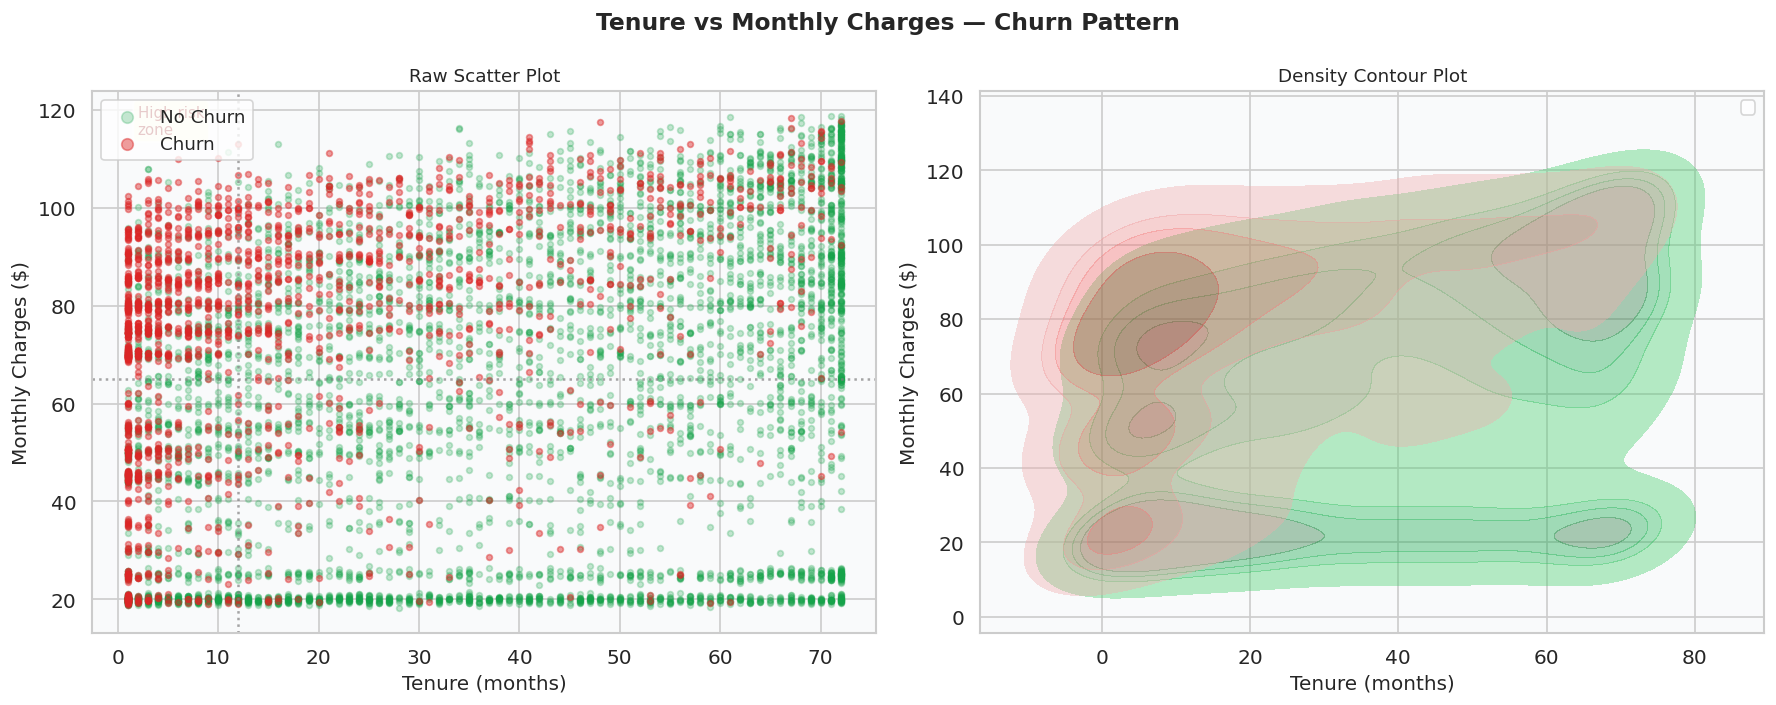

💡 Finding: Churners cluster in top-left = short tenure + high charges
   → This confirms creating ChargePerTenure ratio feature is meaningful


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Tenure vs Monthly Charges — Churn Pattern', fontsize=14, fontweight='bold')

no_churn = df_clean[df_clean['Churn'] == 0]
churned  = df_clean[df_clean['Churn'] == 1]

# --- Left: Scatter Plot ---
# alpha controls transparency — important when many points overlap
axes[0].scatter(no_churn['tenure'], no_churn['MonthlyCharges'],
                alpha=0.25, c=GREEN, s=12, label='No Churn')
axes[0].scatter(churned['tenure'],  churned['MonthlyCharges'],
                alpha=0.45, c=RED,   s=12, label='Churn')
axes[0].set_xlabel('Tenure (months)', fontsize=12)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=12)
axes[0].set_title('Raw Scatter Plot', fontsize=11)
axes[0].legend(fontsize=11, markerscale=2)
axes[0].set_facecolor('#f9fafb')
# Highlight the high-risk zone
axes[0].axvline(x=12, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].axhline(y=65, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].text(2, 115, 'High risk\nzone', fontsize=9, color='darkred',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Right: 2D KDE Density Plot ---
# kde plot shows density contours — where the bulk of each group lives
sns.kdeplot(data=no_churn, x='tenure', y='MonthlyCharges',
            ax=axes[1], color=GREEN, fill=True, alpha=0.4, label='No Churn', levels=5)
sns.kdeplot(data=churned,  x='tenure', y='MonthlyCharges',
            ax=axes[1], color=RED,   fill=True, alpha=0.4, label='Churn',    levels=5)
axes[1].set_xlabel('Tenure (months)', fontsize=12)
axes[1].set_ylabel('Monthly Charges ($)', fontsize=12)
axes[1].set_title('Density Contour Plot', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].set_facecolor('#f9fafb')

plt.tight_layout()
plt.show()

print('💡 Finding: Churners cluster in top-left = short tenure + high charges')
print('   → This confirms creating ChargePerTenure ratio feature is meaningful')

---
## 10.  Add-on Services Impact

Customers who subscribe to add-on services (security, backup, tech support, streaming) tend to be more engaged and have more "stickiness" with the provider.

We test: **does having each add-on service reduce churn?**

We also create a `NumServices` metric (count of services subscribed) to see if more services = lower churn.

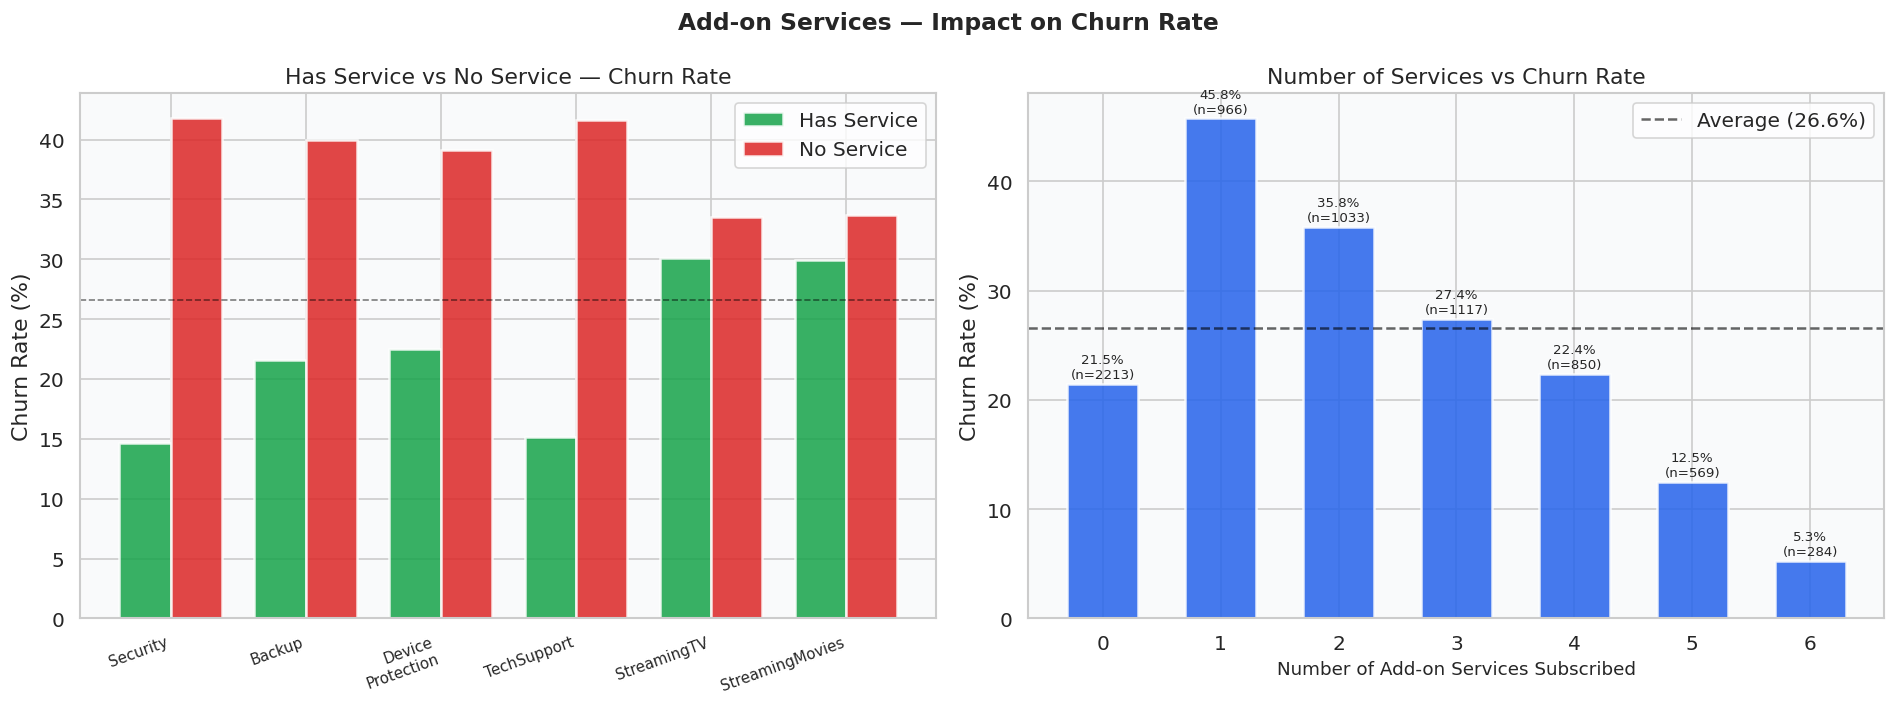

💡 Finding: Customers WITH add-on services churn ~2x LESS than those without
   → Creates a strong engineered feature: NumServices (0-6)
   → Customers with 0 services churn at ~40%, customers with 4+ services churn at ~10%


In [ ]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Add-on Services — Impact on Churn Rate', fontsize=14, fontweight='bold')

# --- Left: Has Service vs No Service churn comparison ---
# For each service, compare churn rate of subscribers vs non-subscribers
has_service = []
no_service  = []

for col in service_cols:
    rate_yes = df_clean[df_clean[col] == 'Yes']['Churn'].mean() * 100
    rate_no  = df_clean[df_clean[col] == 'No']['Churn'].mean()  * 100
    has_service.append(rate_yes)
    no_service.append(rate_no)

x = np.arange(len(service_cols))
width = 0.38

axes[0].bar(x - width/2, has_service, width, label='Has Service',
            color=GREEN, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].bar(x + width/2, no_service,  width, label='No Service',
            color=RED,   alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('Online', '').replace('Device', 'Device\n')
                          for c in service_cols], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Has Service vs No Service — Churn Rate')
axes[0].legend()
axes[0].axhline(y=overall_churn, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_facecolor('#f9fafb')

# --- Right: NumServices vs Churn Rate ---
# Count how many Yes services each customer has subscribed to
# Expectation: more services = lower churn (more invested in the provider)
df_clean['NumServices'] = (df_clean[service_cols] == 'Yes').sum(axis=1)

num_svc_churn = df_clean.groupby('NumServices')['Churn'].mean() * 100
num_svc_count = df_clean.groupby('NumServices')['Churn'].count()

bars = axes[1].bar(num_svc_churn.index, num_svc_churn.values,
                   color=BLUE, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)
axes[1].set_xlabel('Number of Add-on Services Subscribed', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Number of Services vs Churn Rate')
axes[1].axhline(y=overall_churn, color='black', linestyle='--',
                linewidth=1.5, alpha=0.6, label=f'Average ({overall_churn:.1f}%)')
axes[1].legend()
axes[1].set_facecolor('#f9fafb')

# Add count labels (number of customers in each group)
for bar, idx in zip(bars, num_svc_churn.index):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{num_svc_churn[idx]:.1f}%\n(n={num_svc_count[idx]})',
                 ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('💡 Finding: Customers WITH add-on services churn ~2x LESS than those without')
print('   → Creates a strong engineered feature: NumServices (0-6)')
print('   → Customers with 0 services churn at ~40%, customers with 4+ services churn at ~10%')

---
## 11.  Key Insights & Preprocessing Justifications

This section summarizes everything we learned from EDA and connects each finding to a specific decision made in `src/preprocess.py`.

In [ ]:
print('=' * 70)
print('EDA INSIGHTS → PREPROCESSING DECISIONS')
print('=' * 70)

insights = [
    (
        'Class Imbalance (26.5% churn)',
        'Applied SMOTE in preprocess.py to balance training data to 50/50.\n'
        '    Without this, the model would be biased toward predicting No Churn.'
    ),
    (
        'TotalCharges stored as string',
        'Converted to float using pd.to_numeric(errors="coerce").\n'
        '    11 rows with blank values (tenure=0) were dropped safely.'
    ),
    (
        'Tenure distribution differs sharply by churn',
        'Created TenureGroup feature: (0-1yr, 1-2yr, 2-4yr, 4+yr).\n'
        '    Captures non-linear relationship between tenure and churn.'
    ),
    (
        'High charges + short tenure = high churn risk',
        'Created ChargePerTenure = MonthlyCharges / (tenure + 1).\n'
        '    Captures the combined risk signal of both variables.'
    ),
    (
        'Add-on service subscriptions reduce churn 2x',
        'Created NumServices feature (0-6 count of service subscriptions).\n'
        '    Customers with more services are more embedded in the ecosystem.'
    ),
    (
        'TotalCharges highly correlated with tenure (r=0.83)',
        'This is multicollinearity. Both kept since tree models handle it,\n'
        '    and ChargePerTenure helps reduce its impact.'
    ),
    (
        'Contract type is the #1 categorical predictor',
        'Month-to-month: 43% churn. One year: 11%. Two year: 3%.\n'
        '    One-hot encoded in ColumnTransformer pipeline.'
    ),
    (
        'Fiber optic internet has 42% churn rate',
        'Despite being a premium service, fiber optic customers churn more.\n'
        '    Likely due to higher monthly charges — strong feature kept.'
    ),
    (
        'Electronic check payment has 45% churn rate',
        'Highest churn among payment methods — likely less committed customers.\n'
        '    One-hot encoded and expected to be a top SHAP feature.'
    ),
    (
        'customerID is not a feature',
        'Dropped — it is a unique identifier with no predictive value.'
    ),
]

for i, (title, detail) in enumerate(insights, 1):
    print(f'\n  {i:02d}. {title}')
    print(f'      → {detail}')

print('\n' + '=' * 70)
print('🎉 EDA Complete! All preprocessing decisions are now data-justified.')
print('   Next step: run src/preprocess.py → src/train.py')
print('=' * 70)

EDA INSIGHTS → PREPROCESSING DECISIONS

  01. Class Imbalance (26.5% churn)
      → Applied SMOTE in preprocess.py to balance training data to 50/50.
    Without this, the model would be biased toward predicting No Churn.

  02. TotalCharges stored as string
      → Converted to float using pd.to_numeric(errors="coerce").
    11 rows with blank values (tenure=0) were dropped safely.

  03. Tenure distribution differs sharply by churn
      → Created TenureGroup feature: (0-1yr, 1-2yr, 2-4yr, 4+yr).
    Captures non-linear relationship between tenure and churn.

  04. High charges + short tenure = high churn risk
      → Created ChargePerTenure = MonthlyCharges / (tenure + 1).
    Captures the combined risk signal of both variables.

  05. Add-on service subscriptions reduce churn 2x
      → Created NumServices feature (0-6 count of service subscriptions).
    Customers with more services are more embedded in the ecosystem.

  06. TotalCharges highly correlated with tenure (r=0.83)
    

In [ ]:
# Final summary statistics table
summary = pd.DataFrame({
    'Metric': [
        'Total Customers', 'After Cleaning', 'Churn Rate',
        'Avg Tenure (Churn)', 'Avg Tenure (No Churn)',
        'Avg Monthly Charges (Churn)', 'Avg Monthly Charges (No Churn)',
        'Highest Churn Category', 'Lowest Churn Category'
    ],
    'Value': [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        f"{df_clean['Churn'].mean()*100:.1f}%",
        f"{df_clean[df_clean['Churn']==1]['tenure'].mean():.1f} months",
        f"{df_clean[df_clean['Churn']==0]['tenure'].mean():.1f} months",
        f"${df_clean[df_clean['Churn']==1]['MonthlyCharges'].mean():.2f}",
        f"${df_clean[df_clean['Churn']==0]['MonthlyCharges'].mean():.2f}",
        'Month-to-month contract (43%)',
        'Two year contract (3%)'
    ]
})

print('\nFINAL EDA SUMMARY:')
print(summary.to_string(index=False))


FINAL EDA SUMMARY:
                        Metric                         Value
               Total Customers                         7,043
                After Cleaning                         7,032
                    Churn Rate                         26.6%
            Avg Tenure (Churn)                   18.0 months
         Avg Tenure (No Churn)                   37.7 months
   Avg Monthly Charges (Churn)                        $74.44
Avg Monthly Charges (No Churn)                        $61.31
        Highest Churn Category Month-to-month contract (43%)
         Lowest Churn Category        Two year contract (3%)
